# 01｜PyTorch 框架入门：从模型到训练

对应 KerasTutorial 下的两个 Happy House 版本：它们是同一入门练习的修订版，不必重复做。也与第一周 Application 的 Sequential 部分重叠，可作为复习。

学习顺序：加载数据 → 构建模型 → 损失/优化器 → 训练/评估 → 自己的图片 → 参数与权重保存。

原作业是笑脸二分类；当前仓库缺少 train_happy.h5/test_happy.h5，因此本版明确改用第一周已有的 SIGNS 六分类数据。没有将 0～5 标签错误地当作二分类标签。

## 环境与运行约定

选择已安装 PyTorch 的 Jupyter 内核；需要 torch、numpy、h5py、Pillow、IPython、matplotlib，迁移学习还需要 torchvision。这里不自动安装软件或下载数据。

从上到下运行。遇到 CUDA device-side assert 后先重启内核，不要在失效的 CUDA 上下文中继续执行。若出现 OMP Error #15，应排查环境依赖冲突，不要用 KMP_DUPLICATE_LIB_OK 掩盖它。

本笔记是教学参考实现，不是 Coursera AutoGrader 提交文件。训练默认只跑少量 epoch 以检查流程，不承诺达到原作业准确率。所有绘图直接生成内嵌 PNG。

In [2]:
# 本机 Anaconda 的 MKL/OpenMP 兼容设置；请在全新内核中首先运行本单元。
# 仅限制 MKL 线程层，不关闭错误检测，也不影响 CUDA 计算。
import os
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")
from pathlib import Path
import random
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
import numpy as np
import h5py
from PIL import Image
from IPython.display import display, Image as PNGImage
from io import BytesIO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "device:", device, flush=True)

def find_week2():
    # 支持从 notebook 所在目录或项目根目录启动。
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / "C4 - Convolutional Neural Networks" / "Week 2"):
            if (candidate / "ResNets").is_dir() and (candidate / "KerasTutorial").is_dir():
                return candidate
    raise FileNotFoundError("请从本项目内启动 Jupyter，或手动设置 WEEK2。")

WEEK2 = find_week2()

def stratified_indices(labels, fraction=0.2):
    # 每个类别独立切分，避免少数类别在验证集中消失。
    rng = np.random.default_rng(SEED)
    train, val = [], []
    labels = np.asarray(labels)
    for label in np.unique(labels):
        ids = np.flatnonzero(labels == label)
        if len(ids) < 2:
            raise ValueError("每个类别至少需要两张图片才能划分训练和验证集。")
        rng.shuffle(ids)
        k = min(len(ids)-1, max(1, int(round(len(ids)*fraction))))
        val.extend(ids[:k].tolist())
        train.extend(ids[k:].tolist())
    return train, val

def load_signs(batch_size=16):
    folder = WEEK2.parent / "Week 1" / "datasets"
    arrays = []
    for split in ("train", "test"):
        path = folder / f"{split}_signs.h5"
        if not path.exists():
            raise FileNotFoundError(f"缺少 {path}；请恢复课程数据，LFS 指针需先 git lfs pull。")
        with h5py.File(path, "r") as f:
            x = torch.from_numpy(f[f"{split}_set_x"][:]).permute(0,3,1,2).float()/255
            y = torch.from_numpy(f[f"{split}_set_y"][:].reshape(-1)).long()
        assert y.ndim == 1 and ((y >= 0) & (y < 6)).all()
        arrays.append(TensorDataset(x, y))
    source, test = arrays
    train_ids, val_ids = stratified_indices(source.tensors[1].numpy())
    # Windows/Jupyter 默认 num_workers=0，避免多进程启动问题。
    loaders = [DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)
               for ds, shuffle in [(Subset(source,train_ids),True),
                                    (Subset(source,val_ids),False),(test,False)]]
    return loaders

def run_epoch(model, loader, criterion, optimizer=None, binary=False, freeze_bn=False):
    training = optimizer is not None
    model.train(training)
    if freeze_bn:
        # requires_grad=False 不会冻结 BN 的 running_mean/running_var。
        for layer in model.modules():
            if isinstance(layer, nn.BatchNorm2d):
                layer.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            if binary:
                logits, target = logits.reshape(-1), y.float().reshape(-1)
                loss = criterion(logits, target)
                prediction = (logits >= 0).long()  # sigmoid(logit)>=0.5 等价于 logit>=0
            else:
                target = y.long()
                loss = criterion(logits, target)
                prediction = logits.argmax(dim=1)
            if not torch.isfinite(loss):
                raise ValueError("loss 为 NaN/Inf，请检查输入、学习率和标签。")
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()*len(x)
            correct += (prediction == y.reshape(-1)).sum().item()
            count += len(x)
    if count == 0:
        raise ValueError("数据加载器为空。")
    return loss_sum/count, correct/count

def fit(model, train_loader, val_loader, criterion, optimizer,
        epochs=3, binary=False, freeze_bn=False):
    history = {k: [] for k in ("loss", "accuracy", "val_loss", "val_accuracy")}
    print("开始训练；每轮结束都会输出进度。", flush=True)
    for epoch in range(epochs):
        loss, acc = run_epoch(model, train_loader, criterion, optimizer, binary, freeze_bn)
        vl, va = run_epoch(model, val_loader, criterion, binary=binary, freeze_bn=freeze_bn)
        for k,v in zip(history, (loss,acc,vl,va)):
            history[k].append(v)
        print(f"epoch {epoch+1}/{epochs}: loss={loss:.4f}, acc={acc:.3f}, val_loss={vl:.4f}, val_acc={va:.3f}", flush=True)
    return history

def plot_history(history):
    """使用 PIL 绘制静态曲线，绕过本机 Matplotlib PNG 渲染卡顿。"""
    from PIL import ImageDraw
    import math
    import time

    started = time.perf_counter()
    for key, ylabel in (("loss", "Loss"), ("accuracy", "Accuracy")):
        print(f"[绘图] 开始绘制 {ylabel}……", flush=True)
        train = [float(v) for v in history[key]]
        validation = [float(v) for v in history["val_" + key]]
        if not train or not validation:
            print(f"[绘图] {ylabel} 无数据，跳过。", flush=True)
            continue
        values = train + validation
        if not all(math.isfinite(v) for v in values):
            raise ValueError(f"{ylabel} 中存在 NaN 或无穷大，请检查训练记录。")

        # PIL 直接绘制像素，不使用 Matplotlib、Agg 或 pyplot。
        picture = Image.new("RGB", (800, 450), "white")
        draw = ImageDraw.Draw(picture)
        left, top, right, bottom = 85, 55, 745, 380
        low, high = min(values), max(values)
        margin = max((high - low) * 0.1, 0.01)
        low, high = low - margin, high + margin
        count = max(len(train), len(validation))

        draw.text((left, 15), "Model " + ylabel, fill="black")
        draw.text((450, 15), "Train", fill="blue")
        draw.text((550, 15), "Validation", fill="red")
        draw.text((370, 420), "Epoch", fill="black")

        # 纵轴刻度与网格。
        for i in range(6):
            value = low + (high - low) * i / 5
            y = bottom - (bottom - top) * i / 5
            draw.line([(left, y), (right, y)], fill="#dddddd")
            draw.text((5, y - 5), f"{value:.3f}", fill="black")
        draw.line([(left, top), (left, bottom), (right, bottom)],
                  fill="black", width=2)

        # 最多显示 6 个 epoch 刻度；也支持只有一轮的记录。
        for index in sorted({round(i * (count - 1) / 5) for i in range(6)}):
            x = left + index / max(count - 1, 1) * (right - left)
            draw.text((x - 5, bottom + 10), str(index + 1), fill="black")

        for series, color in ((train, "blue"), (validation, "red")):
            points = [
                (left + i / max(count - 1, 1) * (right - left),
                 bottom - (value - low) / (high - low) * (bottom - top))
                for i, value in enumerate(series)
            ]
            if len(points) > 1:
                draw.line(points, fill=color, width=3)
            for x, y in points:
                draw.ellipse((x - 3, y - 3, x + 3, y + 3), fill=color)

        print(f"[绘图] {ylabel} 绘制完成，开始显示……", flush=True)
        # 显式编码 PNG，避免依赖交互式绘图后端。
        with BytesIO() as stream:
            picture.save(stream, format="PNG")
            display(PNGImage(data=stream.getvalue()))
        picture.close()
        print(f"[绘图] {ylabel} 显示调用完成。", flush=True)
    print(f"[绘图] 全部完成，用时 {time.perf_counter() - started:.2f} 秒。", flush=True)

PyTorch: 2.7.1+cu118 device: cuda


## 1｜输入和标签

原始图像为 NHWC；PyTorch Conv2d 使用 NCHW。六分类标签是形状 (N,) 的 long 整数 0～5。训练集再分出验证集，测试集只用于最后评估，不参与调参。

输入/标签： torch.Size([16, 3, 64, 64]) torch.Size([16]) torch.int64


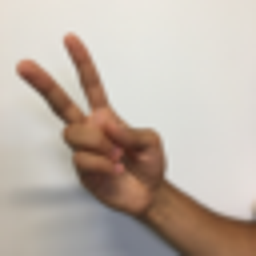

手语数字： 2


In [3]:
train_loader, val_loader, test_loader = load_signs()
x, y = next(iter(train_loader))
print("输入/标签：", x.shape, y.shape, y.dtype)
display(Image.fromarray((x[0].permute(1,2,0).numpy()*255).astype(np.uint8)).resize((256,256)))
print("手语数字：", y[0].item())

## 2｜构建模型：Sequential 与 Module

nn.Sequential 表达线性堆叠；自定义 nn.Module.forward 表达分支和跳跃连接。

卷积参数量为 $(f_h f_w C_{in}+1)C_{out}$；全连接参数量为 $(N_{in}+1)N_{out}$。BatchNorm 的均值/方差是 buffer，不是梯度更新的参数。

In [4]:
def make_classifier(num_classes=6):
    # 输入 (N,3,64,64)，先保留原 Happy House 卷积结构，分类头改为六分类。
    return nn.Sequential(
        nn.ZeroPad2d(3),                     # 64 -> 70
        nn.Conv2d(3,32,7),                   # 70 -> 64，参数 (7*7*3+1)*32=4736    输入3通道，输出32通道：表示32个卷积核，卷积核尺寸为7*7
        nn.BatchNorm2d(32),                  # 可训练 gamma/beta 共 64 个
        nn.ReLU(),
        nn.MaxPool2d(2,2),                   # (N,32,32,32)，不改变通道数
        nn.Flatten(),                       # (N,32768)
        nn.Linear(32*32*32,num_classes),     # (N,6)，不添加 Softmax
    )

In [5]:
# 创建六分类模型，并将模型参数移动到指定设备（CPU 或 GPU）。
model = make_classifier().to(device)

# 打印模型结构，查看各层及其配置。
print(model)

# 统计所有需要训练的参数元素总数：
# model.parameters()：遍历模型的参数张量，例如权重和偏置。
# p.requires_grad：判断该参数是否需要计算梯度。
# p.numel()：返回该张量包含的元素数量，而不是张量的维度数。
print("可训练参数：", sum(p.numel() for p in model.parameters() if p.requires_grad))

# 切换到评估模式：
# BatchNorm 使用已有的运行均值和方差，不更新统计量，
# 避免下面用于检查形状的全零输入影响 BN。
# 注意：eval() 本身不会关闭梯度计算。
model.eval()

# 暂时关闭梯度计算：这里只检查输出形状，不进行训练，
# 因此不需要构建反向传播的计算图，可以节省内存。
with torch.no_grad():
    # 创建两张全零的模拟 RGB 图片，形状为 (批次, 通道, 高度, 宽度)。
    # 输入与模型必须位于同一个设备。
    dummy_input = torch.zeros(2, 3, 64, 64, device=device)

    # 执行前向计算，得到每张图片对应的 6 个类别分数（logits）。
    output = model(dummy_input)

    # 检查输出是否为 (2, 6)：2 张图片，每张图片 6 个类别分数。
    # 满足条件时不输出信息；不满足时抛出 AssertionError。
    assert output.shape == (2, 6), f"输出形状错误：{output.shape}"

# 注意：no_grad() 结束后，模型仍然处于评估模式。
# 后续开始训练时，需要调用 model.train()；
# 如果训练函数内部已经调用，则不必在这里重复调用。

Sequential(
  (0): ZeroPad2d((3, 3, 3, 3))
  (1): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=32768, out_features=6, bias=True)
)
可训练参数： 201414


## 3｜配置损失、优化器并训练

Keras 的 compile/fit 对应这里显式创建 criterion/optimizer，然后执行训练循环。CrossEntropyLoss 内部包含 LogSoftmax；不要把 Softmax 后的概率当作 logits 再传入。

每批顺序：zero_grad → forward → loss → backward → step。每轮 model.train()，验证时 model.eval() 与 no_grad。

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = fit(model, train_loader, val_loader, criterion, optimizer, epochs=3)

开始训练；每轮结束都会输出进度。
epoch 1/3: loss=5.1941, acc=0.440, val_loss=3.7613, val_acc=0.356
epoch 2/3: loss=1.0000, acc=0.722, val_loss=1.9262, val_acc=0.625
epoch 3/3: loss=0.3344, acc=0.891, val_loss=1.5830, val_acc=0.630


[绘图] 开始绘制 Loss……
[绘图] Loss 绘制完成，开始显示……


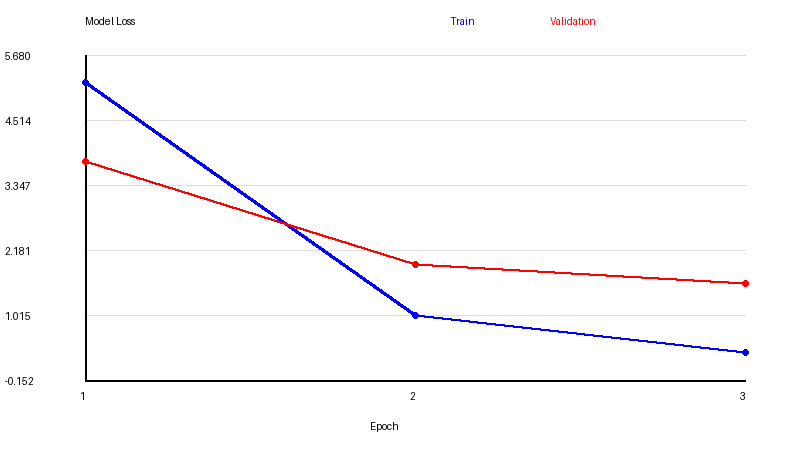

[绘图] Loss 显示调用完成。
[绘图] 开始绘制 Accuracy……
[绘图] Accuracy 绘制完成，开始显示……


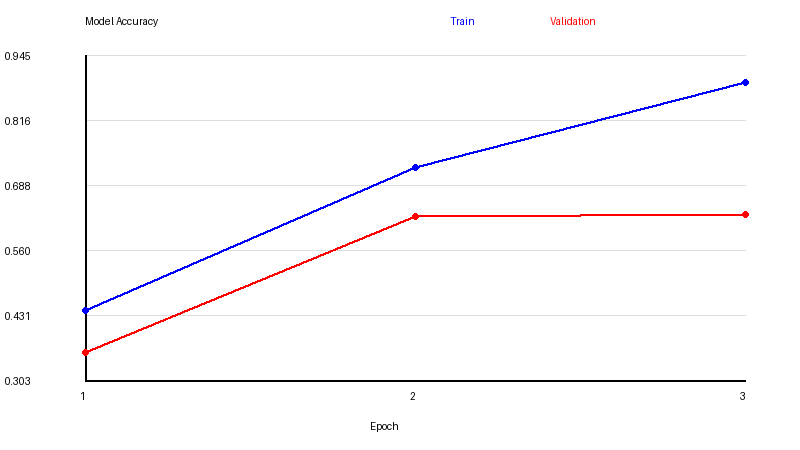

[绘图] Accuracy 显示调用完成。
[绘图] 全部完成，用时 0.03 秒。
独立测试集：loss=1.3323, accuracy=0.675


In [7]:
plot_history(history)
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f"独立测试集：loss={test_loss:.4f}, accuracy={test_acc:.3f}")

## 4｜测试自己的图片（可选）

使用表示数字 0～5 的 RGB 手语图片，而不是笑脸图片；它必须采用与训练时一致的预处理。Softmax 仅在此处用于解释预测概率。

In [11]:
MY_IMAGE = None  # 改成自己的图片路径字符串
if MY_IMAGE is not None:
    with Image.open(MY_IMAGE) as source:
        image = source.convert("RGB").resize((64,64))
    x = torch.from_numpy(np.array(image)).permute(2,0,1).float().unsqueeze(0)/255
    model.eval()
    with torch.no_grad():
        probabilities = model(x.to(device)).softmax(dim=1)[0].cpu()
    display(image.resize((256,256)))
    print("预测数字：", probabilities.argmax().item(), "概率：", probabilities)

## 5｜保存与恢复参数（可选）

state_dict 保存权重和 BN buffer，而不是整个 Python 类定义。恢复时先创建同样的模型，再载入权重。

In [12]:
SAVE = False  # 改为 True 才会写文件
if SAVE:
    destination = WEEK2 / "KerasTutorial" / "signs_classifier.pt"
    torch.save(model.state_dict(), destination)
    restored = make_classifier().to(device)
    restored.load_state_dict(torch.load(destination, map_location=device, weights_only=True))
    restored.eval()

## 复习与下一步

1. 为什么六分类输出是 (N,6)，而不是 (N,1)？
2. 为什么池化不改变通道数？
3. 为什么 eval() 和 no_grad() 不能互相替代？

下一步进入 ResNets，学习顺序执行之外的跳跃连接。参考：[PyTorch 基础教程](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)。